In [6]:
import blackjack.blackjack as blackjack
import bayesian_agent.bayesian as bayes
import random
import matplotlib.pyplot as plt
import importlib
import math
import numpy as np

importlib.reload(blackjack)
importlib.reload(bayes)

<module 'bayesian_agent.bayesian' from '/Users/brianyen/Documents/GitHub/cse150a-blackjack-inference/bayesian_agent/bayesian.py'>

{2: 0.019230769230769232, 3: 0.11538461538461539, 4: 0.15384615384615385, 5: 0.17307692307692307, 6: 0.09615384615384616, 7: 0.038461538461538464, 8: 0.057692307692307696, 9: 0.038461538461538464, 10: 0.25, 11: 0.057692307692307696}
{2: 0.0203, 3: 0.1171, 4: 0.154, 5: 0.1748, 6: 0.0977, 7: 0.0392, 8: 0.0529, 9: 0.0374, 10: 0.2517, 11: 0.0549}
[2, 3, 4, 5, 6, 7, 8, 9, 10, 11] [203, 1171, 1540, 1748, 977, 392, 529, 374, 2517, 549]


(array([ 203., 1171., 1540., 1748.,  977.,  392.,  529.,  374., 2517.,
         549.]),
 array([ 2. ,  2.9,  3.8,  4.7,  5.6,  6.5,  7.4,  8.3,  9.2, 10.1, 11. ]),
 <BarContainer object of 10 artists>)

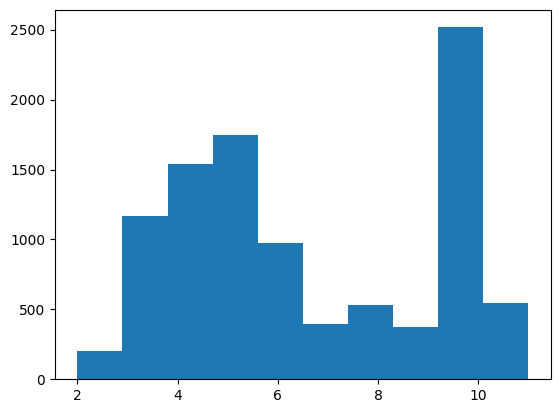

In [7]:
static_deck = []
for _ in range(52):
    static_deck.append(blackjack.random_card())

true_freqs = {item: 0 for item in range(2, 12)}
for item in static_deck:
    true_freqs[item] += 1
true_freqs = {item: value / sum(true_freqs.values()) for item, value in true_freqs.items()}
print(true_freqs)

freqs = {item: 0 for item in range(2, 12)}
for _ in range(10000):
    random.shuffle(static_deck)
    freqs[static_deck[0]] += 1

test_freqs = {item: value / sum(freqs.values()) for item, value in freqs.items()}
print(test_freqs)

lists = sorted(freqs.items())
x, y = zip(*lists)
x = list(x)
y = list(y)
print(x, y)
# plt.hist(y, x)
plt.hist(x, weights=y)
# plt.show()

In [10]:
def P_Y_given_X(i, j):
    if (i == j):
        return 0.91
    else:
        return 0.01
    
def EM(cur_beliefs, observations, t = None):
    sum_P_X_given_D_Y = {i: sum([P_Y_given_X(i, j) * cur_beliefs[j] for j in range(2, 12)]) for i in range(2, 12)}
    P_X_given_D_Y = {i: {j: P_Y_given_X(i, j) * cur_beliefs[j] / sum_P_X_given_D_Y[i] for j in range(2, 12)} for i in range(2, 12)}

    new_beliefs = {i: sum([P_X_given_D_Y[i][observations[t]] for t in range(0, len(observations))]) / len(observations) for i in range(2, 12)}
    new_beliefs = {i: new_beliefs[i] / sum(new_beliefs.values()) for i in range(2, 12)}

    return new_beliefs

In [11]:
def P_Y_given_X2(i, j, t):
    if (i == j):
        return 0.91 + 0.09 * t / (20 + t)
    else:
        return 0.01 - 0.01 * t / (20 + t)
    
def EM2(cur_beliefs, observations, t):
    sum_P_X_given_D_Y = {i: sum([P_Y_given_X2(i, j, t) * cur_beliefs[j] for j in range(2, 12)]) for i in range(2, 12)}
    P_X_given_D_Y = {i: {j: P_Y_given_X2(i, j, t) * cur_beliefs[j] / sum_P_X_given_D_Y[i] for j in range(2, 12)} for i in range(2, 12)}

    new_beliefs = {i: sum([P_X_given_D_Y[i][observations[t]] for t in range(0, len(observations))]) / len(observations) for i in range(2, 12)}
    new_beliefs = {i: new_beliefs[i] / sum(new_beliefs.values()) for i in range(2, 12)}

    return new_beliefs

In [12]:
prob_dict = {2: 4, 3: 4, 4: 4, 5: 4, 6: 4, 7: 4, 8: 4, 9: 4, 10: 16, 11: 4}
num_cards_left = sum(prob_dict.values())
prob_dict = {key: value / num_cards_left for key, value in prob_dict.items()}

prob_dict = EM(prob_dict, [2, 2, 3, 2, 5, 5, 5, 5, 6, 10])

In [13]:
def squared_error(belief, actual):
    return sum([(belief[i] - actual[i]) ** 2 for i in range(2, 12)])

{2: 0.019230769230769232, 3: 0.057692307692307696, 4: 0.057692307692307696, 5: 0.038461538461538464, 6: 0.07692307692307693, 7: 0.09615384615384616, 8: 0.11538461538461539, 9: 0.09615384615384616, 10: 0.36538461538461536, 11: 0.07692307692307693}
{2: 0.04986883265118407, 3: 0.058763540781372255, 4: 0.049868511911109144, 5: 0.053529692237107934, 6: 0.05876354178474263, 7: 0.10992950917215062, 8: 0.11634700530779685, 9: 0.05876354078133071, 10: 0.3636020752814789, 11: 0.08056375009172687}
[0.011094674556213015, 0.02356767579941297, 0.015617266551078708, 0.011780568917365416, 0.010616833757860466, 0.007995410978296293, 0.009480157851475126, 0.0074667679589835905, 0.006919846852983435, 0.007008962070169718, 0.005484993532738234, 0.005885814460199936, 0.0064113107325890085, 0.0071894173522368925, 0.006089237768883361, 0.006443910750160219, 0.007811698812822969, 0.007816218308790477, 0.00802094121002295, 0.008419041627073453, 0.007878785328510765, 0.008393998703608652, 0.008545222256498924, 

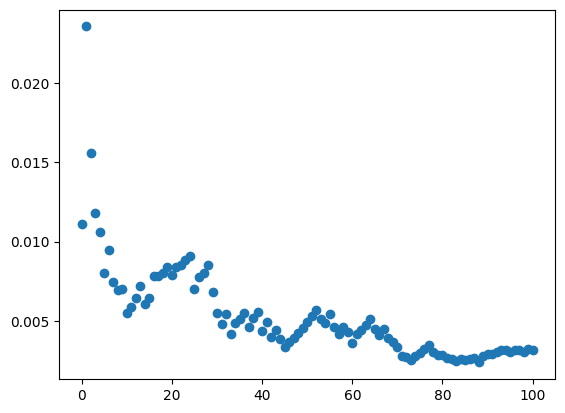

In [11]:
static_deck = []
for _ in range(52):
    static_deck.append(blackjack.random_card())

true_freqs = {item: 0 for item in range(2, 12)}
for item in static_deck:
    true_freqs[item] += 1
true_freqs = {item: value / sum(true_freqs.values()) for item, value in true_freqs.items()}
print(true_freqs)

belief = {2: 4, 3: 4, 4: 4, 5: 4, 6: 4, 7: 4, 8: 4, 9: 4, 10: 16, 11: 4}
belief = {key: value / sum(belief.values()) for key, value in belief.items()}
cards = [2, 3, 4, 5, 6, 7, 8, 9, 10, 10, 10, 10, 11]
error = [squared_error(belief, true_freqs)]
for i in range(1, 101):
    random.shuffle(static_deck)
    cards.append(static_deck[0])
    belief = EM(belief, cards)
    error.append(squared_error(belief, true_freqs))

print(belief)
print(error)

plt.scatter(range(0, 101), error)

{2: 0.11538461538461539, 3: 0.019230769230769232, 4: 0.07692307692307693, 5: 0.11538461538461539, 6: 0.057692307692307696, 7: 0.1346153846153846, 8: 0.07692307692307693, 9: 0.057692307692307696, 10: 0.25, 11: 0.09615384615384616}
{2: 0.12081141711253167, 3: 0.02047235277967051, 4: 0.061814004992401854, 5: 0.11184141038455145, 6: 0.04072816042431917, 7: 0.13517405289726048, 8: 0.06536632221505671, 9: 0.06714439112619586, 10: 0.2880921454405649, 11: 0.08855574262744738}
[0.014053254437869825, 0.012394177060421441, 0.013784591527704828, 0.014180986485298851, 0.012322714255527008, 0.011182150075250228, 0.01242285757784791, 0.011403550139359075, 0.011219406663408486, 0.01192704417390284, 0.012951342818711265, 0.014116894197284348, 0.015424421942060281, 0.014461376153158047, 0.0159073638475908, 0.014036452396476645, 0.015613422120024796, 0.014409494755246118, 0.016044201465474615, 0.01552934594251212, 0.017112420109647267, 0.016738196401527183, 0.015165753381280279, 0.015479682306477553, 0.0

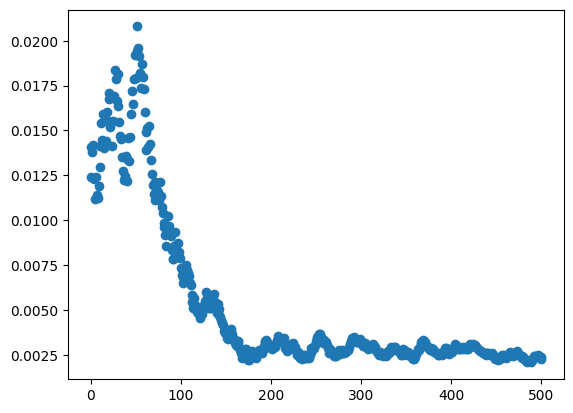

In [12]:
static_deck = []
for _ in range(52):
    static_deck.append(blackjack.random_card())

true_freqs = {item: 0 for item in range(2, 12)}
for item in static_deck:
    true_freqs[item] += 1
true_freqs = {item: value / sum(true_freqs.values()) for item, value in true_freqs.items()}
print(true_freqs)

belief = {2: 4, 3: 4, 4: 4, 5: 4, 6: 4, 7: 4, 8: 4, 9: 4, 10: 16, 11: 4}
belief = {key: value / sum(belief.values()) for key, value in belief.items()}
cards = [2, 3, 4, 5, 6, 7, 8, 9, 10, 10, 10, 10, 11] * 4
error = [squared_error(belief, true_freqs)]
for i in range(1, 501):
    random.shuffle(static_deck)
    cards.append(static_deck[0])
    belief = EM2(belief, cards, i)
    error.append(squared_error(belief, true_freqs))

print(belief)
print(error)

plt.scatter(range(0, 501), error)

{2: 0.057692307692307696, 3: 0.057692307692307696, 4: 0.038461538461538464, 5: 0.11538461538461539, 6: 0.1346153846153846, 7: 0.11538461538461539, 8: 0.057692307692307696, 9: 0.057692307692307696, 10: 0.2692307692307692, 11: 0.09615384615384616}
{2: 0.07246376811594203, 3: 0.03804347826086957, 4: 0.043478260869565216, 5: 0.09782608695652174, 6: 0.13043478260869565, 7: 0.11956521739130435, 8: 0.05434782608695652, 9: 0.05615942028985507, 10: 0.3007246376811594, 11: 0.08695652173913043}
[0.011094674556213019, 0.011839322465195347, 0.011114966599297083, 0.00900264071592743, 0.010336161091655596, 0.010936227988220318, 0.01184751176747884, 0.010209055413240775, 0.010545693622616701, 0.010145321054816022, 0.008597891742452698, 0.006991126496621002, 0.006018283099112426, 0.005532544378698225, 0.005491303568226644, 0.005855701181454733, 0.006124465101042156, 0.0068143346644146405, 0.00784989735539186, 0.008583315041511674, 0.008289045949302359, 0.00907102590381312, 0.009508408936683364, 0.01052

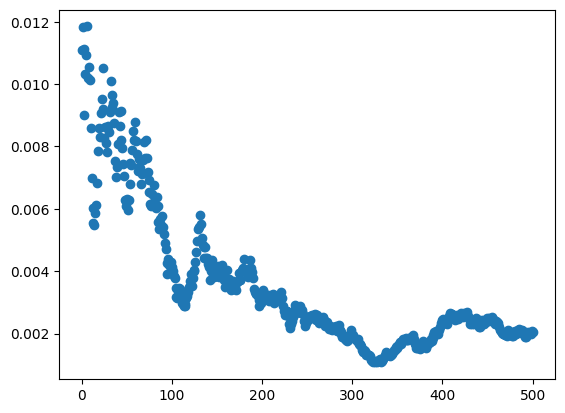

In [13]:
static_deck = []
for _ in range(52):
    static_deck.append(blackjack.random_card())

true_freqs = {item: 0 for item in range(2, 12)}
for item in static_deck:
    true_freqs[item] += 1
true_freqs = {item: value / sum(true_freqs.values()) for item, value in true_freqs.items()}
print(true_freqs)

cards = [2, 3, 4, 5, 6, 7, 8, 9, 10, 10, 10, 10, 11] * 4
belief = {i: 0 for i in range(2, 12)}
for card in cards:
    belief[card] += 1
belief = {key: value / sum(belief.values()) for key, value in belief.items()}
error = [squared_error(belief, true_freqs)]
for i in range(1, 501):
    random.shuffle(static_deck)
    cards.append(static_deck[0])
    
    belief = {i: 0 for i in range(2, 12)}
    for card in cards:
        belief[card] += 1
    belief = {key: value / sum(belief.values()) for key, value in belief.items()}

    error.append(squared_error(belief, true_freqs))

print(belief)
print(error)

plt.scatter(range(0, 501), error)

In [14]:
def simple_count(belief, cards, t = None):
    belief = {i: 0 for i in range(2, 12)}
    for card in cards:
        belief[card] += 1
    return {key: value / sum(belief.values()) for key, value in belief.items()}

{2: 0.09615384615384616, 3: 0.057692307692307696, 4: 0.11538461538461539, 5: 0.09615384615384616, 6: 0.057692307692307696, 7: 0.057692307692307696, 8: 0.019230769230769232, 9: 0.09615384615384616, 10: 0.36538461538461536, 11: 0.038461538461538464}


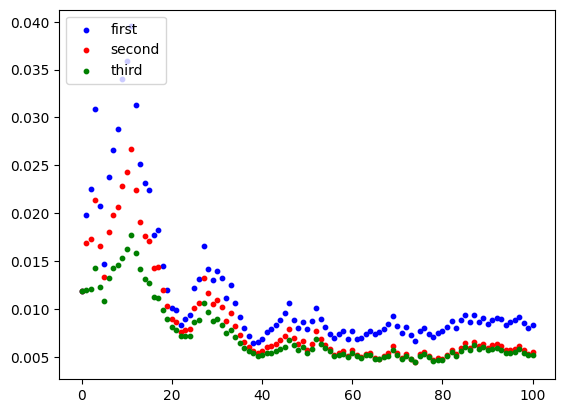

In [15]:
static_deck = []
for _ in range(52):
    static_deck.append(blackjack.random_card())

true_freqs = {item: 0 for item in range(2, 12)}
for item in static_deck:
    true_freqs[item] += 1
true_freqs = {item: value / sum(true_freqs.values()) for item, value in true_freqs.items()}
print(true_freqs)

belief = {2: 4, 3: 4, 4: 4, 5: 4, 6: 4, 7: 4, 8: 4, 9: 4, 10: 16, 11: 4}
belief = {key: value / sum(belief.values()) for key, value in belief.items()}
cards = [2, 3, 4, 5, 6, 7, 8, 9, 10, 10, 10, 10, 11]
error = [squared_error(belief, true_freqs)]
belief2 = {2: 4, 3: 4, 4: 4, 5: 4, 6: 4, 7: 4, 8: 4, 9: 4, 10: 16, 11: 4}
belief2 = {key: value / sum(belief2.values()) for key, value in belief2.items()}
cards2 = [2, 3, 4, 5, 6, 7, 8, 9, 10, 10, 10, 10, 11] * 2
error2 = [squared_error(belief2, true_freqs)]
cards3 = [2, 3, 4, 5, 6, 7, 8, 9, 10, 10, 10, 10, 11] * 4
belief3 = {i: 0 for i in range(2, 12)}
for card in cards3:
    belief3[card] += 1
belief3 = {key: value / sum(belief3.values()) for key, value in belief3.items()}
error3 = [squared_error(belief, true_freqs)]
for i in range(1, 101):
    random.shuffle(static_deck)
    cards.append(static_deck[0])
    cards2.append(static_deck[0])
    belief = EM(belief, cards)
    belief2 = EM2(belief2, cards2, i)
    error.append(squared_error(belief, true_freqs))
    error2.append(squared_error(belief2, true_freqs))

    cards3.append(static_deck[0])
    
    belief3 = {i: 0 for i in range(2, 12)}
    for card in cards3:
        belief3[card] += 1
    belief3 = {key: value / sum(belief3.values()) for key, value in belief3.items()}
    error3.append(squared_error(belief3, true_freqs))

x = range(0, 101)
fig = plt.figure()
ax1 = fig.add_subplot(111)

ax1.scatter(x, error, s=10, c='b', marker="o", label='first')
ax1.scatter(x,error2, s=10, c='r', marker="o", label='second')
ax1.scatter(x,error3, s=10, c='g', marker="o", label='third')
plt.legend(loc='upper left')
plt.show()

In [16]:
def test_inference(strategies, cards, beliefs, errors, iter = 101):
    static_deck = []
    for _ in range(52):
        static_deck.append(blackjack.random_card())

    true_freqs = {item: 0 for item in range(2, 12)}
    for item in static_deck:
        true_freqs[item] += 1
    true_freqs = {item: value / sum(true_freqs.values()) for item, value in true_freqs.items()}

    for i in range(1, iter):
        random.shuffle(static_deck)

        for j in range(len(strategies)):
            cards[j].append(static_deck[0])
            beliefs[j] = strategies[j](beliefs[j], cards[j], i)
            errors[j].append(squared_error(beliefs[j], true_freqs))

    return errors

def plot_error_trends(errors, iter = 100, label = None, ylim = None):
    x = range(0, iter)
    fig = plt.figure()
    ax1 = fig.add_subplot(111)

    c = ['b', 'r', 'g', 'y', 'm', 'c']
    if label is None:
        label = ['first', 'second', 'third', 'fourth']

    for i in range(len(errors)):
        ax1.plot(x, errors[i], c=c[i % len(c)], label=label[i % len(label)])
    
    if ylim is not None:
        plt.ylim(0, ylim)
        
    plt.legend(loc='upper left')
    plt.show()

In [17]:
def llhood(beliefs, true_freqs):
    ll = 0.0
    for i in range(2, 12):
        ll += true_freqs[i] * math.log(beliefs[i])

    return ll

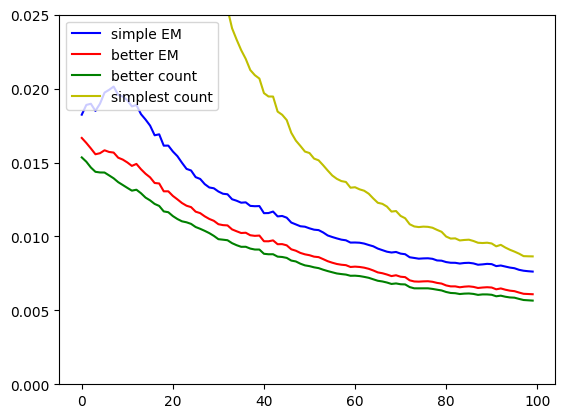

In [156]:
std_deck = {2: 4, 3: 4, 4: 4, 5: 4, 6: 4, 7: 4, 8: 4, 9: 4, 10: 16, 11: 4}

tot_errors = []
n = 100
for i in range(n):
    strategies = [EM, EM2, simple_count, simple_count]
    cards = [[2, 3, 4, 5, 6, 7, 8, 9, 10, 10, 10, 10, 11] * 1, 
             [2, 3, 4, 5, 6, 7, 8, 9, 10, 10, 10, 10, 11] * 2, 
             [2, 3, 4, 5, 6, 7, 8, 9, 10, 10, 10, 10, 11] * 4,
             []]
    beliefs = [{key: value / sum(std_deck.values()) for key, value in std_deck.items()},
            {key: value / sum(std_deck.values()) for key, value in std_deck.items()},
            simple_count(None, cards[2]),
            None]
    errors = [[], [], [], []]

    if len(tot_errors) == 0:
        tot_errors = np.float32(test_inference(strategies, cards, beliefs, errors))
    else:
        tot_errors += np.float32(test_inference(strategies, cards, beliefs, errors))

plot_error_trends(tot_errors / n, label=['simple EM', 'better EM', 'better count', 'simplest count'], ylim=0.025)

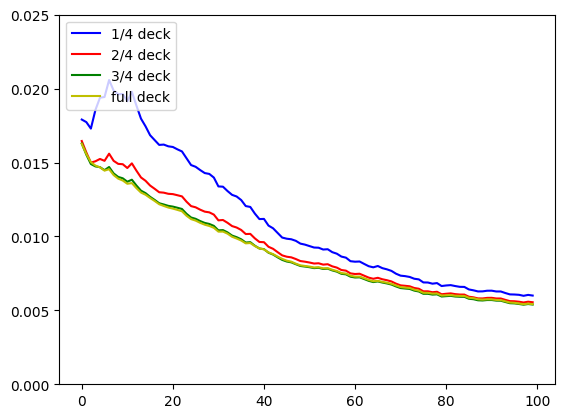

In [161]:
std_deck = {2: 4, 3: 4, 4: 4, 5: 4, 6: 4, 7: 4, 8: 4, 9: 4, 10: 16, 11: 4}

tot_errors = []
n = 100
iter = 100
for i in range(n):
    strategies = [EM2, EM2, EM2, EM2]
    cards = [[2, 3, 4, 5, 6, 7, 8, 9, 10, 10, 10, 10, 11] * 1, 
             [2, 3, 4, 5, 6, 7, 8, 9, 10, 10, 10, 10, 11] * 2, 
             [2, 3, 4, 5, 6, 7, 8, 9, 10, 10, 10, 10, 11] * 3, 
             [2, 3, 4, 5, 6, 7, 8, 9, 10, 10, 10, 10, 11] * 4]
    beliefs = [{key: value / sum(std_deck.values()) for key, value in std_deck.items()},
               {key: value / sum(std_deck.values()) for key, value in std_deck.items()},
               {key: value / sum(std_deck.values()) for key, value in std_deck.items()},
               {key: value / sum(std_deck.values()) for key, value in std_deck.items()}]
    errors = [[], [], [], []]

    if len(tot_errors) == 0:
        tot_errors = np.float32(test_inference(strategies, cards, beliefs, errors, iter = iter+1))
    else:
        tot_errors += np.float32(test_inference(strategies, cards, beliefs, errors, iter = iter+1))

plot_error_trends(tot_errors / n, label=['1/4 deck', '2/4 deck', '3/4 deck', 'full deck'], iter = iter, ylim=0.025)

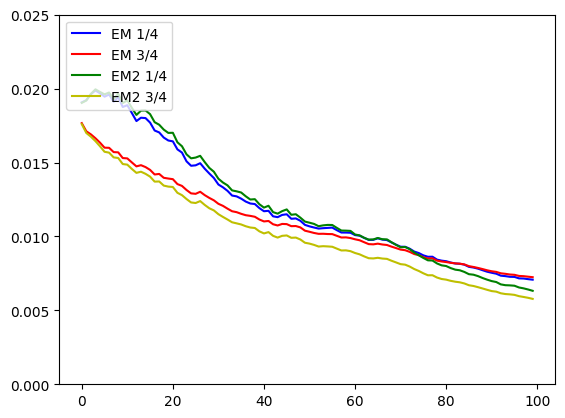

In [162]:
std_deck = {2: 4, 3: 4, 4: 4, 5: 4, 6: 4, 7: 4, 8: 4, 9: 4, 10: 16, 11: 4}

tot_errors = []
n = 100
iter = 100
for i in range(n):
    strategies = [EM, EM, EM2, EM2]
    cards = [[2, 3, 4, 5, 6, 7, 8, 9, 10, 10, 10, 10, 11] * 1, 
             [2, 3, 4, 5, 6, 7, 8, 9, 10, 10, 10, 10, 11] * 3, 
             [2, 3, 4, 5, 6, 7, 8, 9, 10, 10, 10, 10, 11] * 1, 
             [2, 3, 4, 5, 6, 7, 8, 9, 10, 10, 10, 10, 11] * 3]
    beliefs = [{key: value / sum(std_deck.values()) for key, value in std_deck.items()},
               {key: value / sum(std_deck.values()) for key, value in std_deck.items()},
               {key: value / sum(std_deck.values()) for key, value in std_deck.items()},
               {key: value / sum(std_deck.values()) for key, value in std_deck.items()}]
    errors = [[], [], [], []]

    if len(tot_errors) == 0:
        tot_errors = np.float32(test_inference(strategies, cards, beliefs, errors, iter = iter+1))
    else:
        tot_errors += np.float32(test_inference(strategies, cards, beliefs, errors, iter = iter+1))

plot_error_trends(tot_errors / n, label=['EM 1/4', 'EM 3/4', 'EM2 1/4', 'EM2 3/4'], iter = iter, ylim=0.025)

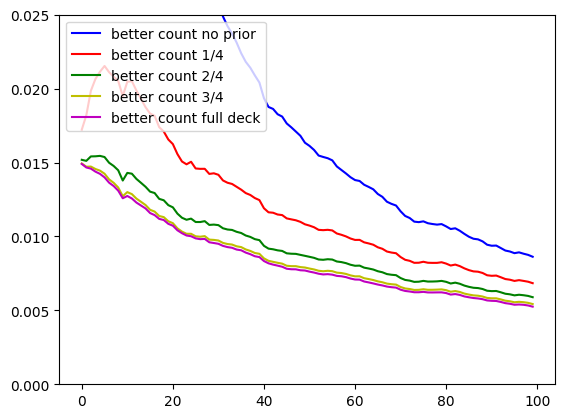

In [18]:
std_deck = {2: 4, 3: 4, 4: 4, 5: 4, 6: 4, 7: 4, 8: 4, 9: 4, 10: 16, 11: 4}

tot_errors = []
n = 100
iter = 100
for i in range(n):
    strategies = [simple_count, simple_count, simple_count, simple_count, simple_count]
    cards = [[2, 3, 4, 5, 6, 7, 8, 9, 10, 10, 10, 10, 11] * 0, 
             [2, 3, 4, 5, 6, 7, 8, 9, 10, 10, 10, 10, 11] * 1, 
             [2, 3, 4, 5, 6, 7, 8, 9, 10, 10, 10, 10, 11] * 2, 
             [2, 3, 4, 5, 6, 7, 8, 9, 10, 10, 10, 10, 11] * 3, 
             [2, 3, 4, 5, 6, 7, 8, 9, 10, 10, 10, 10, 11] * 4]
    beliefs = [None,
               None,
               None,
               None,
               None]
    errors = [[], [], [], [], []]

    if len(tot_errors) == 0:
        tot_errors = np.float32(test_inference(strategies, cards, beliefs, errors, iter = iter+1))
    else:
        tot_errors += np.float32(test_inference(strategies, cards, beliefs, errors, iter = iter+1))

plot_error_trends(tot_errors / n, label=['better count no prior', 'better count 1/4', 'better count 2/4', 'better count 3/4', 'better count full deck'], iter = iter, ylim=0.025)